#**NAME:- Aryan M Dubey**
#**UST24R0101008**

In [ ]:
import os
import gzip
import struct
import urllib.request

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

#Load MNIST

In [ ]:
os.makedirs("mnist", exist_ok=True)

base_url = "https://storage.googleapis.com/cvdf-datasets/mnist/"

files = [
    "train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz"
]

for file in files:
    urllib.request.urlretrieve(
        base_url + file,
        "mnist/" + file
    )

print("MNIST downloaded successfully")

MNIST downloaded successfully


In [ ]:
def load_images(filename):
    with gzip.open(filename, "rb") as f:
        _, n, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
        return data.reshape(n, rows, cols)


def load_labels(filename):
    with gzip.open(filename, "rb") as f:
        _, n = struct.unpack(">II", f.read(8))
        return np.frombuffer(f.read(), dtype=np.uint8)


images = load_images("mnist/train-images-idx3-ubyte.gz")
labels = load_labels("mnist/train-labels-idx1-ubyte.gz")

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: (60000, 28, 28)
Labels: (60000,)


#Select 6,000 images

In [ ]:
images_selected = []
labels_selected = []

for digit in range(10):
    ids = np.where(labels == digit)[0][:600]

    images_selected.extend(images[ids])
    labels_selected.extend(labels[ids])

images = np.array(images_selected)
labels = np.array(labels_selected)

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: (6000, 28, 28)
Labels: (6000,)


#Normalize and Flatten

In [ ]:
images = images / 255.0

X = images.reshape(images.shape[0], -1)

print("Images:", images.shape)
print("Flattened shape:", X.shape)
print("Pixel range:", X.min(), "to", X.max())

Images: (6000, 28, 28)
Flattened shape: (6000, 784)
Pixel range: 0.0 to 1.0


#Display Sample Images

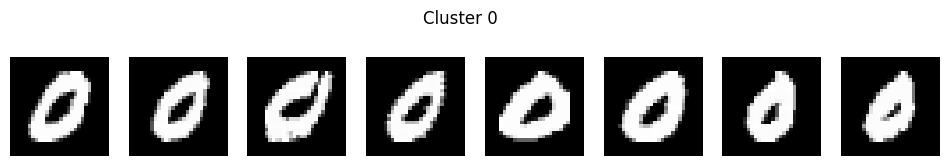

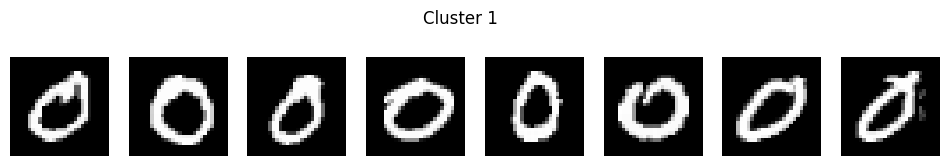

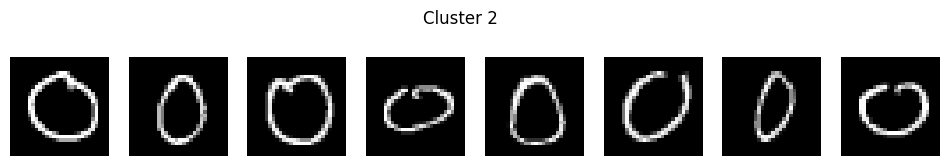

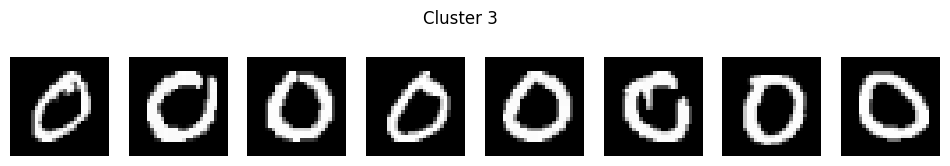

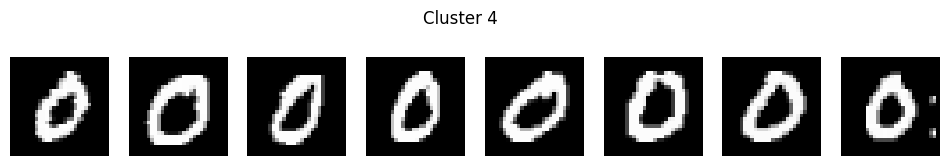

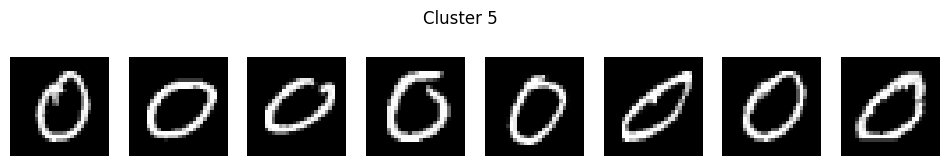

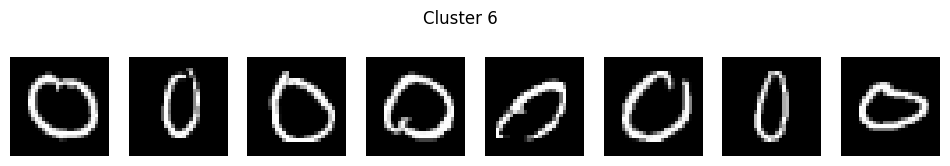

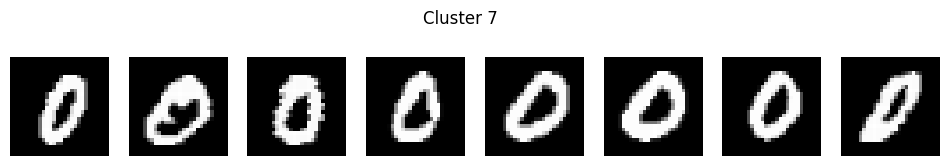

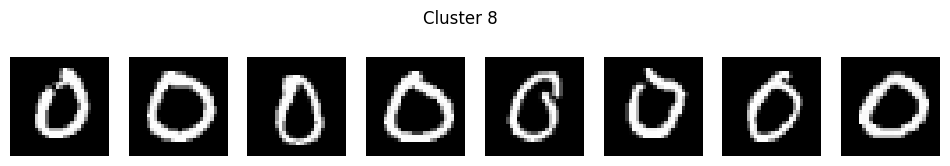

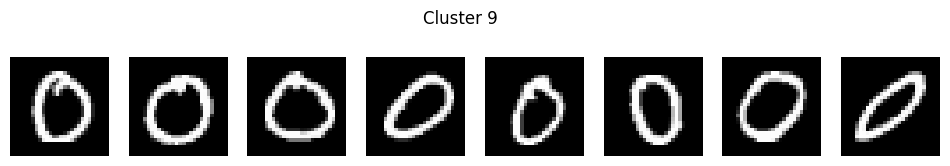

In [29]:
for cluster in range(10):
    ids = np.where(cluster_labels == cluster)[0][:8]

    plt.figure(figsize=(12, 2))
    for j, idx in enumerate(ids):
        plt.subplot(1, 8, j + 1)
        plt.imshow(images[idx], cmap="gray")
        plt.axis("off")

    plt.suptitle("Cluster " + str(cluster))
    plt.show()

In [30]:
for cluster in range(10):
    ids = np.where(cluster_labels == cluster)[0]
    counts = np.bincount(labels[ids], minlength=10)

    print(
        "Cluster", cluster,
        "| Size:", len(ids),
        "| Digit counts:", counts
    )

Cluster 0 | Size: 103 | Digit counts: [19  0  7 14  3  3  9  2 40  6]
Cluster 1 | Size: 835 | Digit counts: [ 96  16  84 122  69  85  90  64 117  92]
Cluster 2 | Size: 210 | Digit counts: [24 77 13  8 22 25  9 22  3  7]
Cluster 3 | Size: 949 | Digit counts: [100  35 114 110  82  78 114 104  94 118]
Cluster 4 | Size: 628 | Digit counts: [ 98   9  77 105  21  32  72  33 116  65]
Cluster 5 | Size: 733 | Digit counts: [ 52 162  46  47 109 102  66  82  14  53]
Cluster 6 | Size: 470 | Digit counts: [ 25 136  36  23  54  59  35  59  11  32]
Cluster 7 | Size: 358 | Digit counts: [43  7 50 45  9 32 31 18 91 32]
Cluster 8 | Size: 896 | Digit counts: [ 80  48  91  73 119  84  94 126  67 114]
Cluster 9 | Size: 818 | Digit counts: [ 63 110  82  53 112 100  80  90  47  81]


#AUTOINCODER

In [ ]:
class Autoencoder:

    def __init__(self, input_size=784, hidden=256, latent=128, lr=0.01):
        self.lr = lr

        self.W1 = np.random.randn(input_size, hidden) * 0.05
        self.W2 = np.random.randn(hidden, latent) * 0.05
        self.W3 = np.random.randn(latent, hidden) * 0.05
        self.W4 = np.random.randn(hidden, input_size) * 0.05

    def relu(self, x):
        return np.maximum(0, x)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -50, 50)))

    def fit(self, X, epochs=50):

        for epoch in range(epochs):

            h1 = self.relu(X @ self.W1)
            z = self.relu(h1 @ self.W2)
            h2 = self.relu(z @ self.W3)
            output = self.sigmoid(h2 @ self.W4)

            loss = np.mean((X - output) ** 2)

            d4 = (output - X) * output * (1 - output)
            d3 = (d4 @ self.W4.T) * (h2 > 0)
            d2 = (d3 @ self.W3.T) * (z > 0)
            d1 = (d2 @ self.W2.T) * (h1 > 0)

            self.W4 -= self.lr * (h2.T @ d4) / len(X)
            self.W3 -= self.lr * (z.T @ d3) / len(X)
            self.W2 -= self.lr * (h1.T @ d2) / len(X)
            self.W1 -= self.lr * (X.T @ d1) / len(X)

            print(f"Epoch {epoch + 1}: Loss = {loss:.6f}")

    def encode(self, X):
        h1 = self.relu(X @ self.W1)
        return self.relu(h1 @ self.W2)

    def predict(self, X):
        h1 = self.relu(X @ self.W1)
        z = self.relu(h1 @ self.W2)
        h2 = self.relu(z @ self.W3)
        return self.sigmoid(h2 @ self.W4)

#Train the Autoencoder

In [ ]:
ae = Autoencoder(
    input_size=784,
    hidden=256,
    latent=128,
    lr=0.005
)

ae.fit(X, epochs=100)

Epoch 1: Loss = 0.231636
Epoch 2: Loss = 0.231463
Epoch 3: Loss = 0.231297
Epoch 4: Loss = 0.231137
Epoch 5: Loss = 0.230978
Epoch 6: Loss = 0.230821
Epoch 7: Loss = 0.230663
Epoch 8: Loss = 0.230502
Epoch 9: Loss = 0.230336
Epoch 10: Loss = 0.230163
Epoch 11: Loss = 0.229982
Epoch 12: Loss = 0.229791
Epoch 13: Loss = 0.229586
Epoch 14: Loss = 0.229364
Epoch 15: Loss = 0.229124
Epoch 16: Loss = 0.228860
Epoch 17: Loss = 0.228568
Epoch 18: Loss = 0.228243
Epoch 19: Loss = 0.227879
Epoch 20: Loss = 0.227467
Epoch 21: Loss = 0.226999
Epoch 22: Loss = 0.226462
Epoch 23: Loss = 0.225843
Epoch 24: Loss = 0.225123
Epoch 25: Loss = 0.224281
Epoch 26: Loss = 0.223288
Epoch 27: Loss = 0.222110
Epoch 28: Loss = 0.220703
Epoch 29: Loss = 0.219011
Epoch 30: Loss = 0.216962
Epoch 31: Loss = 0.214465
Epoch 32: Loss = 0.211410
Epoch 33: Loss = 0.207656
Epoch 34: Loss = 0.203043
Epoch 35: Loss = 0.197392
Epoch 36: Loss = 0.190526
Epoch 37: Loss = 0.182318
Epoch 38: Loss = 0.172740
Epoch 39: Loss = 0.16

#Generate Latent Features

In [17]:
latent = ae.encode(X)

print("Latent shape:", latent.shape)
print("Latent mean:", latent.mean())
print("Latent std:", latent.std())

Latent shape: (6000, 128)
Latent mean: 1.0965380617951033
Latent std: 1.6418842548236607


#K-Means

In [18]:
class KMeans:

    def __init__(self, k=10, iterations=50):
        self.k = k
        self.iterations = iterations

    def fit(self, X):

        np.random.seed(42)

        indices = np.random.choice(len(X), self.k, replace=False)
        self.centers = X[indices].copy()

        for _ in range(self.iterations):

            distances = ((X[:, None] - self.centers[None, :]) ** 2).sum(axis=2)

            self.labels = np.argmin(distances, axis=1)

            for i in range(self.k):
                points = X[self.labels == i]

                if len(points) > 0:
                    self.centers[i] = points.mean(axis=0)

        return self.labels

    def predict(self, X):

        distances = ((X[:, None] - self.centers[None, :]) ** 2).sum(axis=2)

        return np.argmin(distances, axis=1)

Train K-Means

In [25]:
kmeans = KMeans(k=10, iterations=50)
cluster_labels = kmeans.fit(latent)

correct = 0

for cluster in range(10):
    ids = np.where(cluster_labels == cluster)[0]
    counts = np.bincount(labels[ids], minlength=10)
    correct += counts.max()

purity = correct / len(labels)

print("Cluster Purity:", round(purity, 4))
print("Purity Percentage:", round(purity * 100, 2), "%")

Cluster Purity: 0.1833
Purity Percentage: 18.33 %


Cluster Distribution

In [26]:
for i in range(10):
    count = np.sum(cluster_labels == i)
    print("Cluster", i, ":", count, "images")

Cluster 0 : 103 images
Cluster 1 : 835 images
Cluster 2 : 210 images
Cluster 3 : 949 images
Cluster 4 : 628 images
Cluster 5 : 733 images
Cluster 6 : 470 images
Cluster 7 : 358 images
Cluster 8 : 896 images
Cluster 9 : 818 images


Cluster Purity

In [27]:
correct = 0

for cluster in range(10):
    ids = np.where(cluster_labels == cluster)[0]
    counts = np.bincount(labels[ids], minlength=10)
    correct += counts.max()

purity = correct / len(labels)

print("Cluster Purity:", purity)
print("Purity Percentage:", purity * 100, "%")

Cluster Purity: 0.18333333333333332
Purity Percentage: 18.333333333333332 %


In [28]:
latent = ae.encode(X)

print("Latent min:", latent.min())
print("Latent max:", latent.max())
print("Latent mean:", latent.mean())
print("Latent std:", latent.std())

Latent min: 0.0
Latent max: 15.353116895832436
Latent mean: 1.0965380617951033
Latent std: 1.6418842548236607
